<a href="https://colab.research.google.com/github/AmatHub21/Tugas_DataMining_DM/blob/main/DM06%20-%20KLASIFIKASI-%20ENSEMBLE%20METHODS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#TUGAS PERTEMUAN 06

import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression



file_path = "titanic.csv"

if not os.path.exists(file_path):
    print("❌ File tidak ditemukan. Pastikan titanic.csv ada di folder ini:")
    print(os.getcwd())
    exit()

df = pd.read_csv(file_path)
print("✅ File berhasil dibaca")
print("Kolom dataset:", df.columns)


# =========================
# PILIH FITUR (FLEXIBLE)
# =========================
columns_needed = ['Survived','Pclass','Sex','Age','SibSp','Parch','Fare','Embarked']
df = df[[col for col in columns_needed if col in df.columns]]

# =========================
# HANDLE MISSING
# =========================
if 'Age' in df.columns:
    df['Age'] = df['Age'].fillna(df['Age'].median())

if 'Embarked' in df.columns:
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# =========================
# ENCODING
# =========================
le = LabelEncoder()

if 'Sex' in df.columns:
    df['Sex'] = le.fit_transform(df['Sex'])

if 'Embarked' in df.columns:
    df['Embarked'] = le.fit_transform(df['Embarked'])

# =========================
# SPLIT DATA
# =========================
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================
# MODEL
# =========================
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1),
    "Stacking": StackingClassifier(
        estimators=[
            ('dt', DecisionTreeClassifier(max_depth=5)),
            ('rf', RandomForestClassifier(n_estimators=100)),
            ('gb', GradientBoostingClassifier())
        ],
        final_estimator=LogisticRegression(),
        n_jobs=-1
    )
}

# =========================
# EVALUASI
# =========================
def evaluate(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

# =========================
# TRAIN & TEST
# =========================
results = []

for name, model in models.items():
    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        scores = evaluate(y_test, y_pred)
        scores["Model"] = name
        results.append(scores)

    except Exception as e:
        print(f"❌ Error di model {name}: {e}")

# =========================
# HASIL
# =========================
results_df = pd.DataFrame(results)

print("\n=== HASIL ===")
print(results_df.sort_values(by="Accuracy", ascending=False))


✅ File berhasil dibaca
Kolom dataset: Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'Siblings/Spouses Aboard',
       'Parents/Children Aboard', 'Fare'],
      dtype='object')

=== HASIL ===
   Accuracy  Precision    Recall        F1              Model
3  0.831461   0.791045  0.768116  0.779412           Stacking
1  0.814607   0.846154  0.637681  0.727273      Random Forest
0  0.808989   0.818182  0.652174  0.725806      Decision Tree
2  0.803371   0.765625  0.710145  0.736842  Gradient Boosting


In [ ]:
import requests

url = "https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv"
response = requests.get(url)

with open("titanic.csv", "wb") as f:
    f.write(response.content)

print("titanic.csv downloaded successfully!")

titanic.csv downloaded successfully!


Perbandingan Akurasi:
Decision Tree: 0.9415
Bagging: 0.9591
Random Forest: 0.9708

Top 5 Feature Importance:
                 feature  importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975
Perbandingan Boosting Methods:
AdaBoost: 0.9708
Gradient Boosting: 0.9591


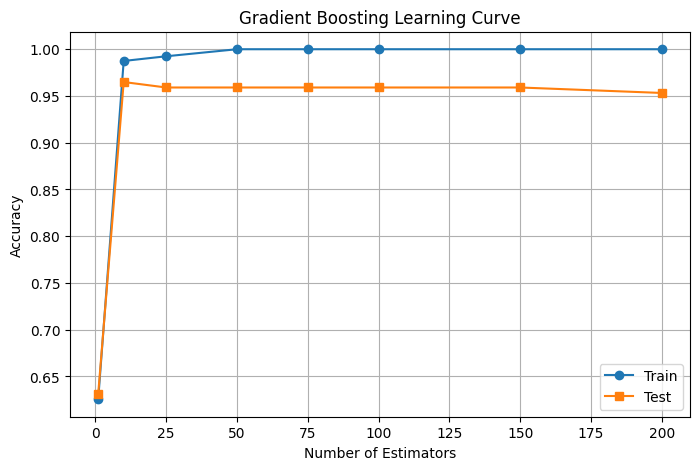

PERBANDINGAN SEMUA METODE
Single Decision Tree: 0.9415
Bagging: 0.9591
Random Forest: 0.9708
AdaBoost: 0.9708
Gradient Boosting: 0.9591
Stacking: 0.9825


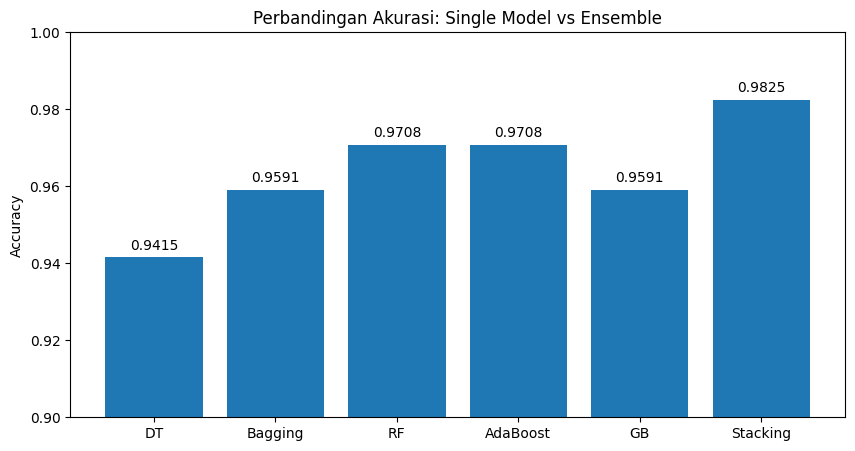

            Model  Mean Accuracy    Std  Training Time (s)
    Decision Tree         0.9332 0.0162             0.0829
    Random Forest         0.9578 0.0102             1.3506
         AdaBoost         0.9736 0.0124             2.4120
Gradient Boosting         0.9613 0.0106             3.9957
         Stacking         0.9596 0.0143             5.9155

Model terbaik berdasarkan CV: AdaBoost


In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
data = load_breast_cancer()
X = data.data
y = data.target

# Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Single Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

# Bagging dengan Decision Tree
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Perbandingan akurasi
print("=" * 50)
print("Perbandingan Akurasi:")
print(f"Decision Tree: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging: {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest: {accuracy_score(y_test, rf_pred):.4f}")

# Feature Importance Random Forest
importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 5 Feature Importance:")
print(importance.head())

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# AdaBoost
ada = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=1.0,
    random_state=42
)

ada.fit(X_train, y_train)
ada_pred = ada.predict(X_test)

# Gradient Boosting
gb = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

# Feature Importance
gb_importance = pd.DataFrame({
    'feature': data.feature_names,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

# Evaluasi
print("=" * 50)
print("Perbandingan Boosting Methods:")
print(f"AdaBoost: {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting: {accuracy_score(y_test, gb_pred):.4f}")

# Learning Curve
train_scores = []
test_scores = []

estimators = [1, 10, 25, 50, 75, 100, 150, 200]

for n in estimators:
    gb_temp = GradientBoostingClassifier(
        n_estimators=n,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    )

    gb_temp.fit(X_train, y_train)

    train_scores.append(gb_temp.score(X_train, y_train))
    test_scores.append(gb_temp.score(X_test, y_test))

# Visualisasi learning curve
plt.figure(figsize=(8, 5))

plt.plot(estimators, train_scores, label='Train', marker='o')
plt.plot(estimators, test_scores, label='Test', marker='s')

plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Gradient Boosting Learning Curve')

plt.legend()
plt.grid(True)

plt.show()

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Base models
base_models = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))
]

# Meta learner
meta_learner = LogisticRegression(max_iter=1000)

# Stacking classifier
stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba'
)

stacking.fit(X_train, y_train)

stacking_pred = stacking.predict(X_test)

# Perbandingan semua metode
print("=" * 50)
print("PERBANDINGAN SEMUA METODE")
print("=" * 50)

print(f"Single Decision Tree: {accuracy_score(y_test, dt_pred):.4f}")
print(f"Bagging: {accuracy_score(y_test, bagging_pred):.4f}")
print(f"Random Forest: {accuracy_score(y_test, rf_pred):.4f}")
print(f"AdaBoost: {accuracy_score(y_test, ada_pred):.4f}")
print(f"Gradient Boosting: {accuracy_score(y_test, gb_pred):.4f}")
print(f"Stacking: {accuracy_score(y_test, stacking_pred):.4f}")

# Visualisasi akurasi
models = ['DT', 'Bagging', 'RF', 'AdaBoost', 'GB', 'Stacking']

scores = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, bagging_pred),
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, ada_pred),
    accuracy_score(y_test, gb_pred),
    accuracy_score(y_test, stacking_pred)
]

plt.figure(figsize=(10, 5))

plt.bar(models, scores)

plt.ylabel('Accuracy')
plt.title('Perbandingan Akurasi: Single Model vs Ensemble')

plt.ylim(0.9, 1.0)

for i, v in enumerate(scores):
    plt.text(i, v + 0.002, f'{v:.4f}', ha='center')

plt.show()

from sklearn.model_selection import cross_val_score, KFold
import time

# List model
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),

    'Random Forest': RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    'AdaBoost': AdaBoostClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=100,
        random_state=42
    ),

    'Stacking': stacking
}

# Cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = []

for name, model in models.items():

    start_time = time.time()

    scores = cross_val_score(
        model,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    elapsed_time = time.time() - start_time

    results.append({
        'Model': name,
        'Mean Accuracy': scores.mean(),
        'Std': scores.std(),
        'Training Time (s)': elapsed_time
    })

# Hasil evaluasi
results_df = pd.DataFrame(results).round(4)

print(results_df.to_string(index=False))

# Model terbaik
best_model = results_df.loc[
    results_df['Mean Accuracy'].idxmax(),
    'Model'
]

print(f"\nModel terbaik berdasarkan CV: {best_model}")

